First five rows of dataset:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

K-Means Silhouette Score: 0.4787241921049546
Hierarchical Clustering Silhouette Score: 0.44553956399200406


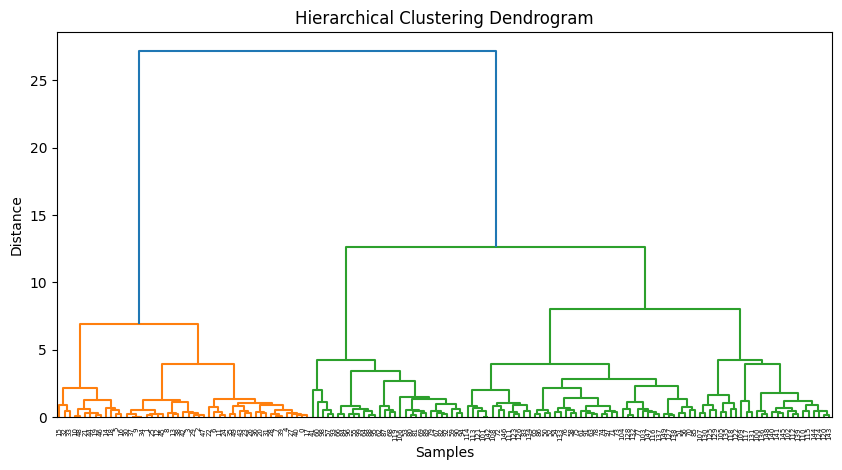

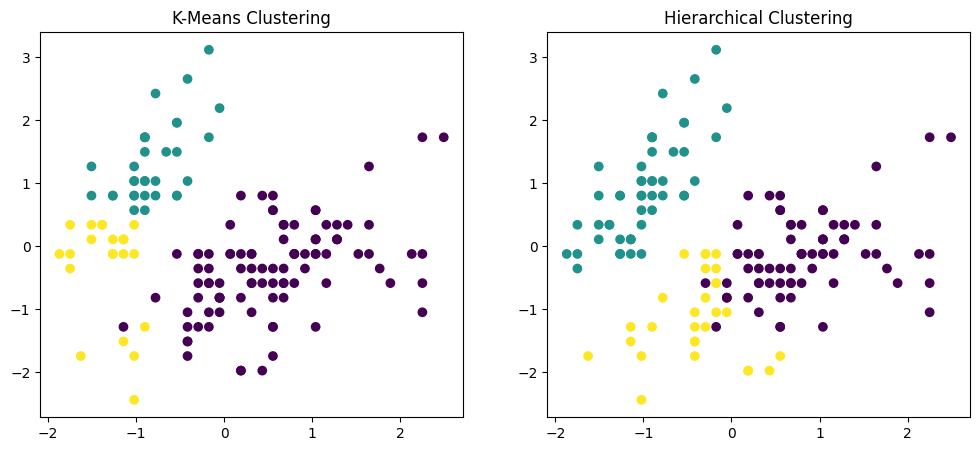

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Load dataset (correct way)
data = pd.read_csv("/content/Iris.csv")

# Drop Id column
data = data.drop("Id", axis=1)

# Features only
df = data.drop("Species", axis=1)

print("First five rows of dataset:")
print(df.head())

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

print("\nK-Means Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))

# Hierarchical
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
df['Hierarchical_Cluster'] = hierarchical_labels

print("Hierarchical Clustering Silhouette Score:", silhouette_score(X_scaled, hierarchical_labels))

# Dendrogram
plt.figure(figsize=(10,5))
linked = linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# Visualization
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("K-Means Clustering")

plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hierarchical_labels)
plt.title("Hierarchical Clustering")

plt.show()